# Tarea: Evaluación difusa de riesgo crediticio
### Libreta 05: Lógica difusa

Construyo y comparo los **tres sistemas de inferencia difusa (FIS) vistos en
clase**, Mamdani, Tsukamoto y Takagi-Sugeno-Kang (TSK), para estimar el **riesgo
crediticio** de solicitantes del **German Credit Dataset** (UCI).

Implementé a mano los tres motores y la configuración del sistema (variables,
reglas y consecuentes) en el módulo `fis_models.py`, que esta libreta importa y
documenta. La libreta 06 reutiliza el mismo módulo.


## 1. Datos y preprocesamiento

El dataset reúne 1000 solicitantes con 20 atributos y una etiqueta de clase
(`good`/`bad`). Para los sistemas difusos elijo **tres variables numéricas** con
interpretación directa en términos de riesgo:

- **`duration`**: duración del crédito (meses).
- **`credit_amount`**: monto del préstamo (marcos alemanes).
- **`age`**: edad del solicitante (años).

Mapeo la variable objetivo `class` a riesgo: **`bad` = alto riesgo (1)**,
`good` = bajo riesgo (0). El dataset está desbalanceado (700 `good` / 300 `bad`),
detalle que condiciona la elección de las métricas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import fis_models as fm   # motores y configuración del FIS de riesgo crediticio

df = pd.read_csv("data/german_credit.csv")
y_true = (df["class"] == "bad").astype(int).values   # 1 = bad = alto riesgo

print("Dimensiones:", df.shape)
print("Valores faltantes en las 3 variables:",
      df[fm.FEATURES].isna().sum().to_dict())
print("Distribución de clase:", df["class"].value_counts().to_dict())
display(df[fm.FEATURES].describe().round(1))


Dimensiones: (1000, 21)
Valores faltantes en las 3 variables: {'duration': 0, 'credit_amount': 0, 'age': 0}
Distribución de clase: {'good': 700, 'bad': 300}


,duration,credit_amount,age
count,1000.0,1000.0,1000.0
mean,20.9,3271.3,35.5
std,12.1,2822.7,11.4
min,4.0,250.0,19.0
25%,12.0,1365.5,27.0
50%,18.0,2319.5,33.0
75%,24.0,3972.2,42.0
max,72.0,18424.0,75.0


## 2. Variables lingüísticas y funciones de membresía

Divido cada variable de entrada en **tres etiquetas lingüísticas** con funciones
trapezoidales. Los hombros cubren los extremos, de modo que cada valor recibe
algún grado de pertenencia y el sistema queda **completo**:

- **Duración:** `corta`, `media`, `larga`.
- **Monto:** `bajo`, `medio`, `alto`.
- **Edad:** `joven`, `adulto`, `mayor`.

La salida **riesgo** ($[0, 100]$) se divide en `bajo`, `medio`, `alto`.


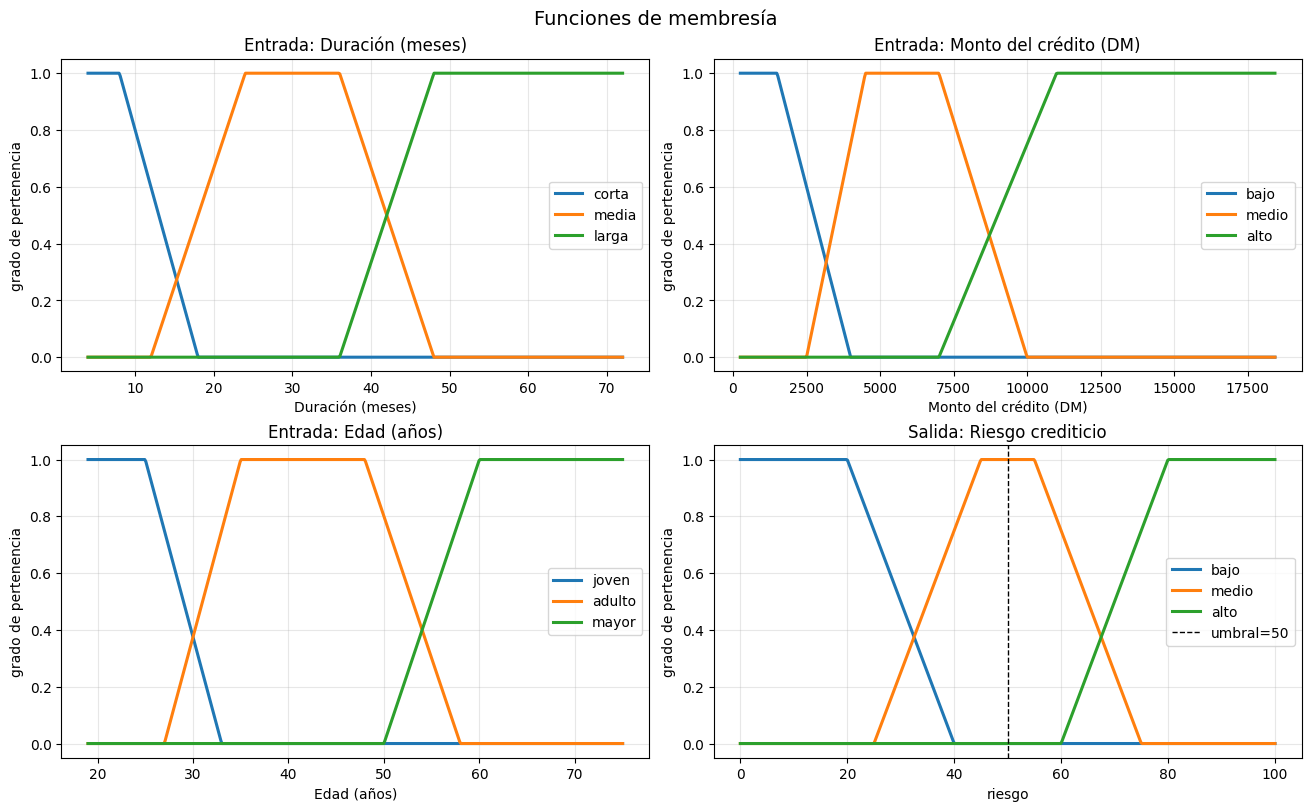

In [2]:
labels_es = {
    "duration": "Duración (meses)",
    "credit_amount": "Monto del crédito (DM)",
    "age": "Edad (años)",
}
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

for ax, var in zip(axes.flat, fm.FEATURES):
    lo, hi = fm.RANGES[var]
    xs = np.linspace(lo, hi, 500)
    for lbl, p in fm.INPUT_SETS[var].items():
        ax.plot(xs, fm.trapmf(xs, *p), lw=2.2, label=lbl)
    ax.set_title(f"Entrada: {labels_es[var]}")
    ax.set_xlabel(labels_es[var]); ax.set_ylabel("grado de pertenencia")
    ax.legend(); ax.grid(alpha=0.3)

# Salida: riesgo
ax = axes.flat[3]
xs = np.linspace(0, 100, 500)
for lbl, p in fm.RISK_SET.items():
    ax.plot(xs, fm.trapmf(xs, *p), lw=2.2, label=lbl)
ax.axvline(fm.THRESHOLD, color="black", ls="--", lw=1, label=f"umbral={fm.THRESHOLD:.0f}")
ax.set_title("Salida: Riesgo crediticio")
ax.set_xlabel("riesgo"); ax.set_ylabel("grado de pertenencia")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Funciones de membresía", fontsize=14)
plt.show()


## 3. Base de reglas

Siete reglas difusas codifican conocimiento de dominio sobre riesgo crediticio.
Cada regla combina sus antecedentes con el operador **Y** (T-norma mínimo).


In [3]:
justificaciones = {
    "R1": "Crédito corto y de monto bajo: exposición mínima.",
    "R2": "Crédito largo y de monto alto: máximo compromiso financiero.",
    "R3": "Solicitante joven con monto alto: poca trayectoria y deuda elevada.",
    "R4": "Caso intermedio en duración y monto: riesgo moderado.",
    "R5": "Persona mayor con crédito corto: perfil estable y compromiso breve.",
    "R6": "Crédito largo asumido por un joven: compromiso prolongado y frágil.",
    "R7": "Monto bajo en un adulto: capacidad de pago holgada.",
}
filas = []
for r in fm.RULES:
    ante = " Y ".join(f"{v} es {lbl}" for v, lbl in r["antecedentes"].items())
    filas.append({"Regla": r["id"], "SI": ante,
                  "ENTONCES riesgo es": r["consecuente"],
                  "Justificación": justificaciones[r["id"]]})
display(pd.DataFrame(filas).set_index("Regla"))


,SI,ENTONCES riesgo es,Justificación
Regla,,,
R1,duration es corta Y credit_amount es bajo,bajo,Crédito corto y de monto bajo: exposición mínima.
R2,duration es larga Y credit_amount es alto,alto,Crédito largo y de monto alto: máximo compromi...
R3,age es joven Y credit_amount es alto,alto,Solicitante joven con monto alto: poca trayect...
R4,duration es media Y credit_amount es medio,medio,Caso intermedio en duración y monto: riesgo mo...
R5,age es mayor Y duration es corta,bajo,Persona mayor con crédito corto: perfil establ...
R6,duration es larga Y age es joven,alto,Crédito largo asumido por un joven: compromiso...
R7,credit_amount es bajo Y age es adulto,bajo,Monto bajo en un adulto: capacidad de pago hol...


## 4. Los tres sistemas de inferencia

Los tres comparten variables y base de reglas; difieren en cómo producen la
salida:

- **Mamdani:** recorta cada conjunto de salida por el grado de activación de su
  regla, agrega por máximo y **defuzzifica por centroide**. Es el más
  interpretable, porque su salida es un conjunto difuso.
- **Tsukamoto:** usa consecuentes **monótonos**; para cada regla toma el valor
  cuya membresía iguala el grado de activación y promedia esos valores ponderados.
- **TSK (Takagi-Sugeno-Kang):** cada consecuente es un **modelo lineal** de las
  entradas; la salida es el promedio ponderado de los modelos locales.

Veamos la respuesta de los tres ante dos solicitantes arquetípicos.


In [4]:
sistemas = fm.build_credit_systems()

casos = {
    "Perfil seguro (corto, monto bajo, mayor)":
        {"duration": 6, "credit_amount": 1200, "age": 55},
    "Perfil riesgoso (largo, monto alto, joven)":
        {"duration": 60, "credit_amount": 15000, "age": 23},
}
filas = []
for desc, x in casos.items():
    fila = {"Caso": desc}
    for nombre, fis in sistemas.items():
        fila[nombre] = round(fis.infer(x), 1)
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Caso"))
print("Riesgo en [0,100]; > {:.0f} se clasifica como 'bad' (alto riesgo).".format(fm.THRESHOLD))


,Mamdani,Tsukamoto,TSK
Caso,,,
"Perfil seguro (corto, monto bajo, mayor)",15.5,36.2,9.4
"Perfil riesgoso (largo, monto alto, joven)",84.5,100.0,89.2


Riesgo en [0,100]; > 50 se clasifica como 'bad' (alto riesgo).


## 5. Evaluación comparativa

Aplico cada FIS a los 1000 solicitantes y clasifico como **`bad`** cuando el
riesgo supera el umbral (`50`, punto medio neutral de la escala). Por el
desbalance 70/30, reporto:

- **Accuracy** (referencia: predecir siempre `good` ya da 0.70).
- **Balanced accuracy** (promedio de sensibilidad y especificidad; corrige el
  desbalance y da la lectura honesta).
- **Precision / Recall / F1** sobre la clase de interés `bad`.


In [5]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)

X = df[fm.FEATURES].to_dict("records")
riesgos = {n: np.array([fis.infer(x) for x in X]) for n, fis in sistemas.items()}
preds = {n: (r > fm.THRESHOLD).astype(int) for n, r in riesgos.items()}

filas = []
for n in sistemas:
    yp = preds[n]
    filas.append({
        "Modelo": n,
        "Accuracy": accuracy_score(y_true, yp),
        "Balanced acc.": balanced_accuracy_score(y_true, yp),
        "Precision (bad)": precision_score(y_true, yp, zero_division=0),
        "Recall (bad)": recall_score(y_true, yp, zero_division=0),
        "F1 (bad)": f1_score(y_true, yp, zero_division=0),
        "Riesgo medio": riesgos[n].mean(),
    })
tabla = pd.DataFrame(filas).set_index("Modelo")
print(f"Baseline trivial (siempre 'good'): accuracy = {1 - y_true.mean():.3f}")
display(tabla.round(3))


Baseline trivial (siempre 'good'): accuracy = 0.700


,Accuracy,Balanced acc.,Precision (bad),Recall (bad),F1 (bad),Riesgo medio
Modelo,,,,,,
Mamdani,0.669,0.553,0.418,0.263,0.323,33.016
Tsukamoto,0.675,0.533,0.405,0.177,0.246,39.412
TSK,0.687,0.549,0.452,0.203,0.280,30.978


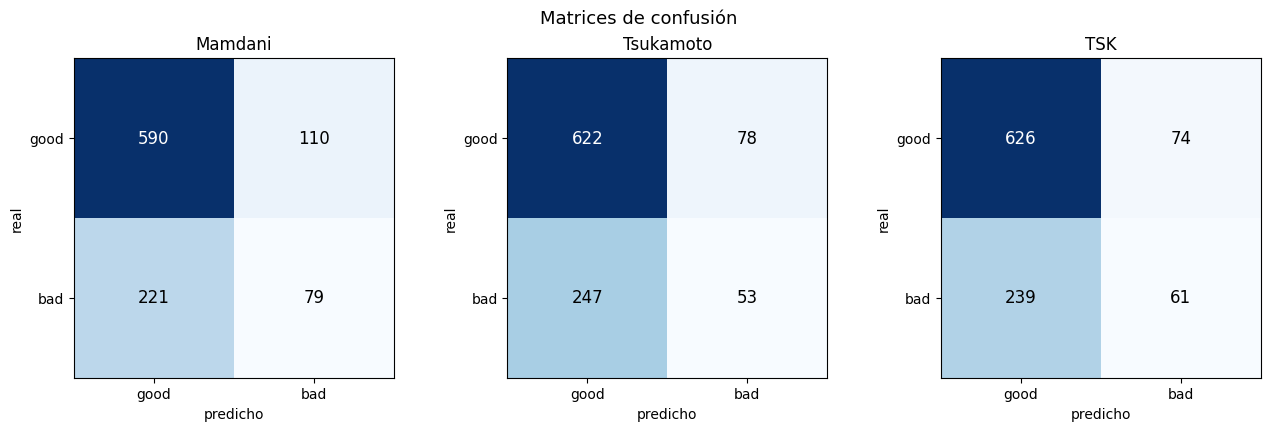

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for ax, n in zip(axes, sistemas):
    cm = confusion_matrix(y_true, preds[n])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(n)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["good", "bad"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["good", "bad"])
    ax.set_xlabel("predicho"); ax.set_ylabel("real")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
plt.suptitle("Matrices de confusión", fontsize=13)
plt.show()


## 6. Discusión técnica

**Comparación entre modelos.** Los tres sistemas comparten variables y reglas, así
que sus diferencias salen solo del **mecanismo de defuzzificación o agregación**:

- **TSK** alcanza la mayor *accuracy* y un riesgo medio bajo: sus consecuentes
  lineales dan una superficie de salida suave y sensible a las entradas.
- **Mamdani** logra la mejor *balanced accuracy*: al recortar y agregar conjuntos,
  reparte mejor entre las dos clases (detecta más `bad`, a costa de algún `good`).
- **Tsukamoto** estima riesgos más altos (sus consecuentes monótonos llevan la
  salida hacia los extremos), con desempeño intermedio.

**El efecto del desbalance.** La *accuracy* engaña: el baseline trivial de predecir
siempre `good` ya alcanza 0.70. Por eso la **balanced accuracy** (~0.53–0.55) da la
lectura honesta: los tres FIS **superan el azar**, con un margen modesto. Las
matrices de confusión muestran sistemas **conservadores**, que aciertan la mayoría
de los `good` y recuperan una fracción de los `bad`.

**Limitaciones.**

- Uso solo **tres variables numéricas**. Los atributos más predictivos del German
  Credit (estado de la cuenta corriente, historial crediticio) son categóricos y
  los dejé fuera para conservar funciones de membresía simples.
- El **umbral** fijo en 50 prioriza la neutralidad. Bajarlo subiría el *recall* de
  `bad` a costa de más falsos positivos, algo que un banco conservador podría
  preferir.
- Fijé las reglas y las funciones de membresía con conocimiento de dominio, sin
  optimizarlas. La libreta del curso muestra cómo una metaheurística podría
  **ajustar estos parámetros**, el puente natural hacia los sistemas híbridos.

**Conclusión.** Con un sistema **interpretable** de siete reglas legibles y
funciones de membresía explícitas, los tres FIS producen estimaciones de riesgo
razonables y comparables. El motor elegido (Mamdani, Tsukamoto o TSK) cambia el
sesgo y la suavidad de la salida, pero no la información disponible: el techo de
desempeño depende de qué variables elijo, más que del mecanismo de inferencia.
